# Car Price Prediction with Machine Learning

## Project Overview

This project predicts the selling price of used cars using Linear Regression. The workflow includes data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [2]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Dataset Overview

In [3]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 301
Columns : 9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


## Data Cleaning

In [6]:
print("Missing Values")
df.isnull().sum()

Missing Values


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 2


In [8]:
df.drop_duplicates(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (299, 9)


In [9]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Observation

- No missing values were found in the dataset.
- 2 Duplicate records were removed.
- The dataset is ready for exploratory data analysis.

## Exploratory Data Analysis

### Numerical Feature Distribution

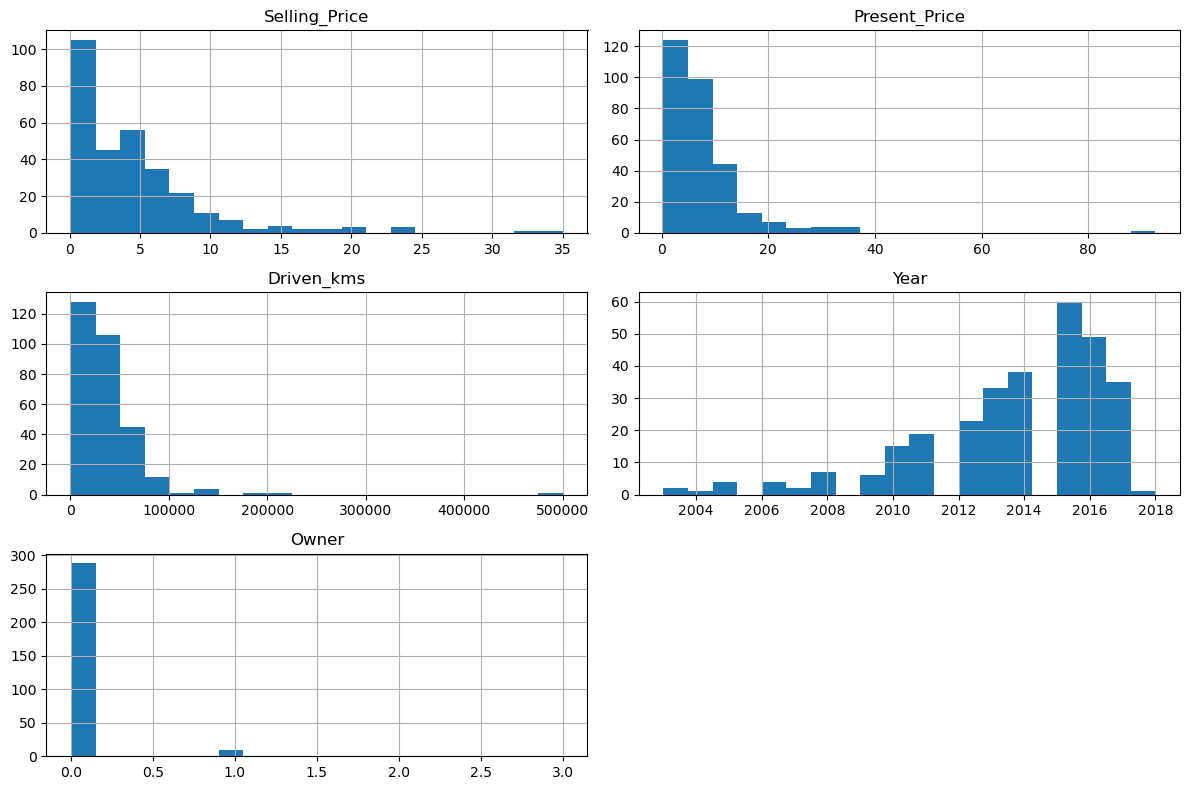

In [10]:
numerical_features = [
    "Selling_Price",
    "Present_Price",
    "Driven_kms",
    "Year",
    "Owner"
]

df[numerical_features].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

**Observation**

Most numerical features show a varied distribution. The target variable (Selling_Price) contains a few high-value cars, while most vehicles fall within the lower price range.

### Correlation Heatmap

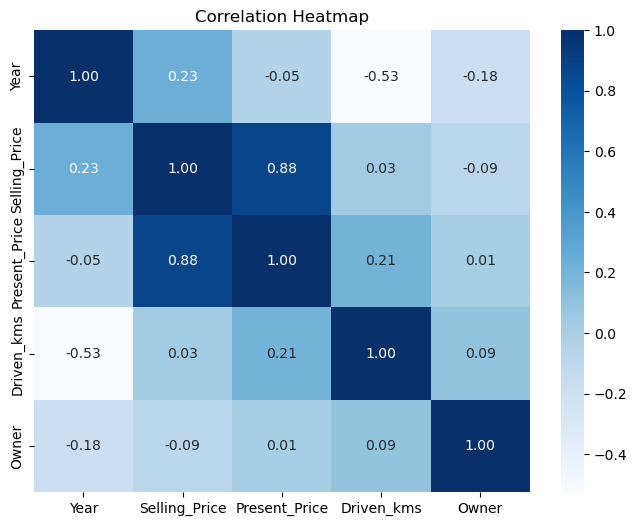

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**Observation**

Present Price has the strongest positive relationship with Selling Price. Car age and kilometers driven are expected to influence the selling price during model training.

### Pair Plot

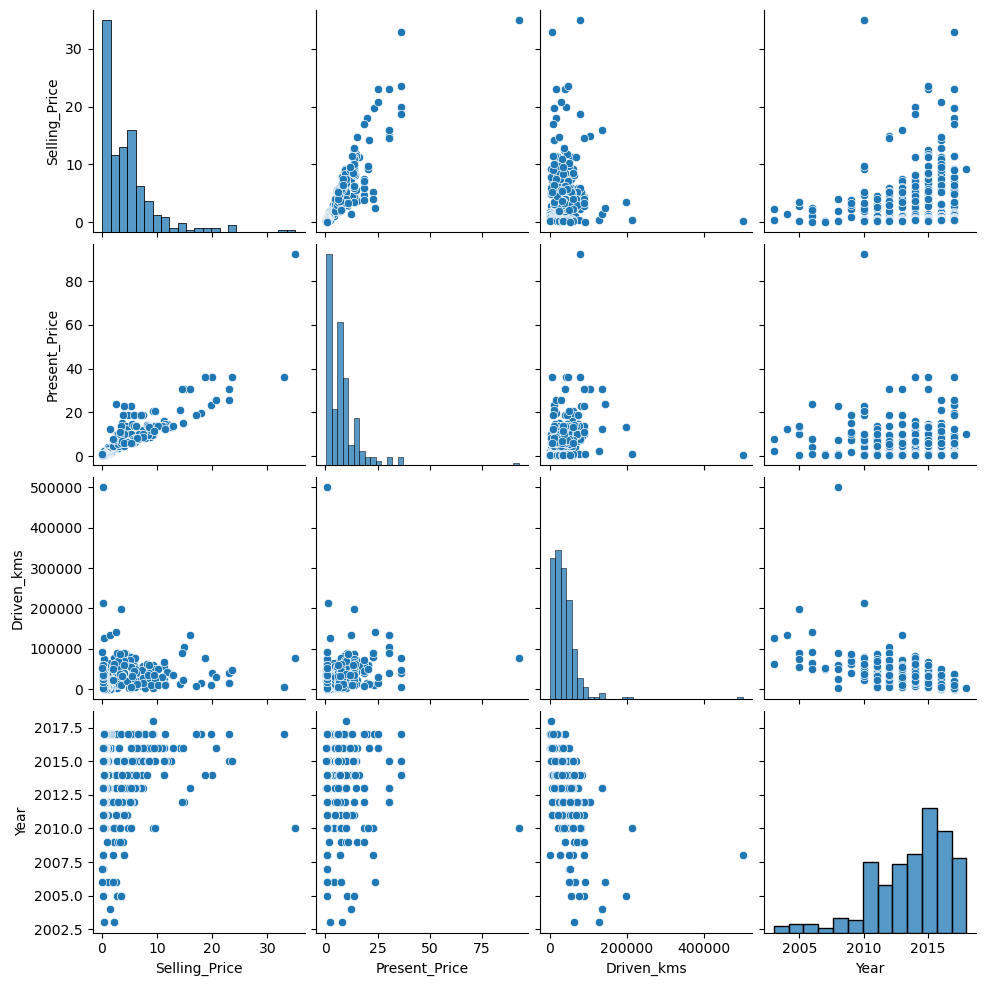

In [12]:
sns.pairplot(
    df[
        [
            "Selling_Price",
            "Present_Price",
            "Driven_kms",
            "Year"
        ]
    ]
)

plt.show()

**Observation**

The pair plot helps visualize relationships between the numerical features. Present Price appears to have a strong positive relationship with Selling Price.

### Selling Price vs Present Price

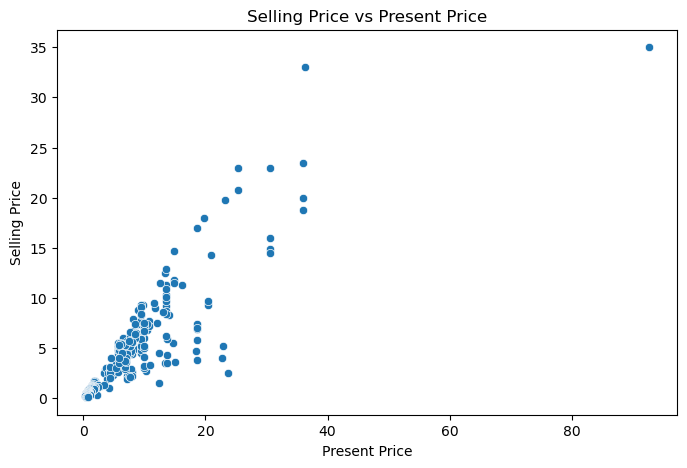

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Selling Price vs Present Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

**Observation**

Cars with a higher present price generally have a higher selling price, indicating a strong positive relationship.

### Selling Price by Fuel Type

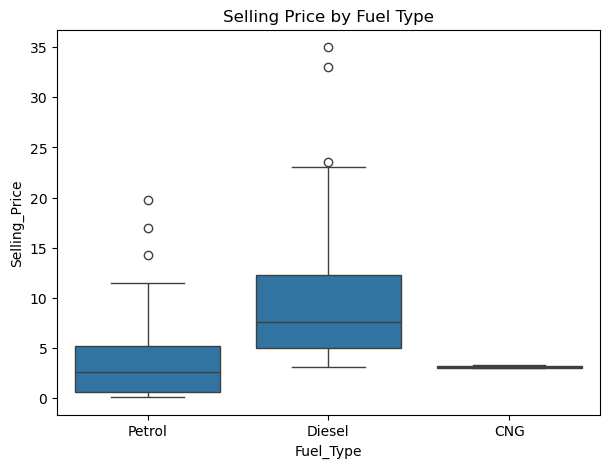

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")

plt.show()

**Observation**

The distribution of selling prices varies across different fuel types, suggesting that fuel type may influence the resale value.

### Number of Cars by Fuel Type

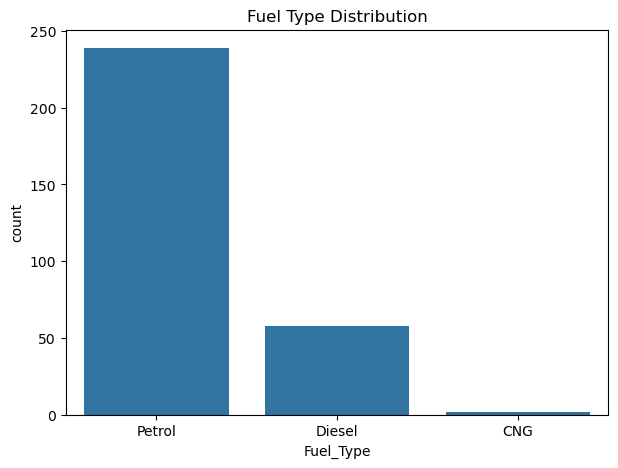

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Fuel_Type"
)

plt.title("Fuel Type Distribution")

plt.show()

**Observation**

Petrol cars make up the largest portion of the dataset, followed by Diesel and CNG vehicles.

## Feature Engineering

In [16]:
current_year = datetime.now().year

df["Car_Age"] = current_year - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


**Observation**

A new feature, `Car_Age`, is created to represent the age of each car. This feature is expected to be more useful than the manufacturing year for predicting selling price.

In [17]:
df.drop("Year", axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## Encoding Categorical Features

In [18]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')

In [19]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

In [20]:
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,ritz,3.35,5.59,27000,0,12,False,True,False,True
1,sx4,4.75,9.54,43000,0,13,True,False,False,True
2,ciaz,7.25,9.85,6900,0,9,False,True,False,True
3,wagon r,2.85,4.15,5200,0,15,False,True,False,True
4,swift,4.60,6.87,42450,0,12,True,False,False,True


**Observation**

Categorical features have been converted into numerical format using one-hot encoding.

## Feature Selection

In [21]:
X = df.drop(["Car_Name", "Selling_Price"], axis=1)

y = df["Selling_Price"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (299, 8)
Target Shape : (299,)


## Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 239
Testing Samples : 60


**Observation**

The dataset has been divided into training and testing sets. The training data will be used to build the model, while the testing data will be used to evaluate its performance.

## Model Training

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Prediction

In [24]:
y_pred = model.predict(X_test)

## Model Evaluation

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")

MAE  : 1.47
MSE  : 6.37
RMSE : 2.52
R² Score : 0.75


### Observation

The model performs well on the test data. The evaluation metrics indicate how closely the predicted prices match the actual selling prices.

## Training and Testing Score

In [32]:
print(f"Training Score : {model.score(X_train, y_train):.3f}")
print(f"Testing Score  : {model.score(X_test, y_test):.3f}")

Training Score : 0.905
Testing Score  : 0.753


## Actual vs Predicted Prices

In [26]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head()

,Actual Price,Predicted Price
283,8.99,7.500495
267,8.35,7.791134
166,0.45,1.365253
9,7.45,7.008954
78,5.25,11.165011


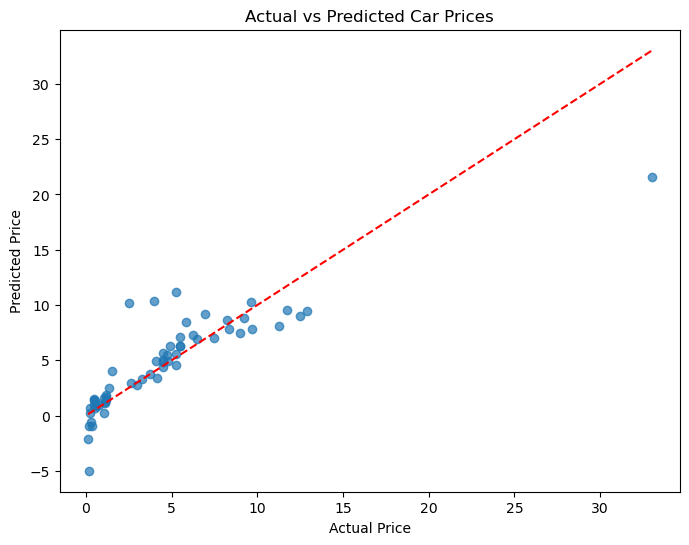

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

### Observation

Most predicted values are close to the actual prices, indicating that the Linear Regression model captures the overall trend of the data.

## Model Coefficients

In [29]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Fuel_Type_Diesel,2.142391
5,Fuel_Type_Petrol,0.692516
2,Owner,0.640144
0,Present_Price,0.437119
1,Driven_kms,-0.000011
3,Car_Age,-0.330031
6,Selling_type_Individual,-1.302291
7,Transmission_Manual,-1.573425


### Observation

The coefficients show how each feature influences the predicted selling price. Positive values increase the prediction, while negative values decrease it.

## Predicting the Selling Price of a New Car

In [31]:
sample_car = pd.DataFrame(
    [[
        7.5,
        35000,
        0,
        5,
        0,
        1,
        0,
        1
    ]],
    columns=X.columns
)

predicted_price = model.predict(sample_car)

print(f"Estimated Selling Price : {predicted_price[0]:.2f} Lakhs")

Estimated Selling Price : 7.00 Lakhs


## Business Insights

- Present Price is the strongest factor affecting the selling price.
- Older cars generally have a lower resale value.
- Fuel type and transmission also contribute to the selling price.
- The model can help estimate the resale value of used cars based on available features.

### Conclusion

The Linear Regression model successfully predicts the selling price of used and new cars using vehicle-related features. The project demonstrates a complete machine learning workflow, from data preparation to prediction and evaluation.